## EDA

In [1]:
import pandas as pd

df = pd.read_csv('dataset_anonymized_meaningful.csv')
# Базовая описательная статистика
print("Размер (строк, столбцов):", df.shape)
print("\nТипы данных:")
print(df.dtypes)

Размер (строк, столбцов): (545506, 19)

Типы данных:
order_dttm                     str
currency_rate              float64
currency_nm                    str
ecom_flg                      bool
client_type                    str
registration_country_nm        str
okved                          str
turnover_amount_amt        float64
sales_currency                 str
order_status                   str
order_uuid                     str
currency_uuid                  str
contract_uuid                  str
client_uuid                    str
product_uuid                   str
order_cnum                     str
client_nm                      str
product_nm                     str
product_category               str
dtype: object


In [2]:
print("\nПропуски:")
print(df.isnull().sum())


Пропуски:
order_dttm                      0
currency_rate                   0
currency_nm                     2
ecom_flg                        0
client_type                    54
registration_country_nm        66
okved                      122804
turnover_amount_amt             0
sales_currency                  0
order_status                    0
order_uuid                      0
currency_uuid                   0
contract_uuid                   0
client_uuid                     0
product_uuid                    0
order_cnum                      0
client_nm                      54
product_nm                      0
product_category            15151
dtype: int64


#### Категориальные признаки

In [3]:
# 'string'
print("\nКатегориальные признаки:")
display(df.describe(include=['string']))


Категориальные признаки:


,order_dttm,currency_nm,client_type,registration_country_nm,okved,sales_currency,order_status,order_uuid,currency_uuid,contract_uuid,client_uuid,product_uuid,order_cnum,client_nm,product_nm,product_category
count,545506,545504,545452,545440,422702,545506,545506,545506,545506,545506,545506,545506,545506,545452,545506,530355
unique,182070,7,4,14,1274,2,2,182385,8,51325,27077,19989,168732,4229,1848,19
top,2025-12-02 14:17:12.000,руб.,Юр. лицо,РОССИЯ,Производство электромонтажных работ,USD,implementation,b3a10935-fe20-f2e4-97ae-74b32f381737,baafd897-8857-2fc9-b1bb-4bc9b37c3653,7ec66bdd-a47c-25d7-1b7e-f044e3c67f42,bff498c8-ab61-02fd-8d6a-ec54eec7dc60,398a29a6-3638-13f8-c19c-d4bb1c55cda4,00000011477,"ИП ""КомфортГарант""",Продвинутый контроллер,Отделочные материалы
freq,3117,460438,468805,537118,26214,410335,410335,3117,460438,8429,13967,5876,3125,13985,5969,86343


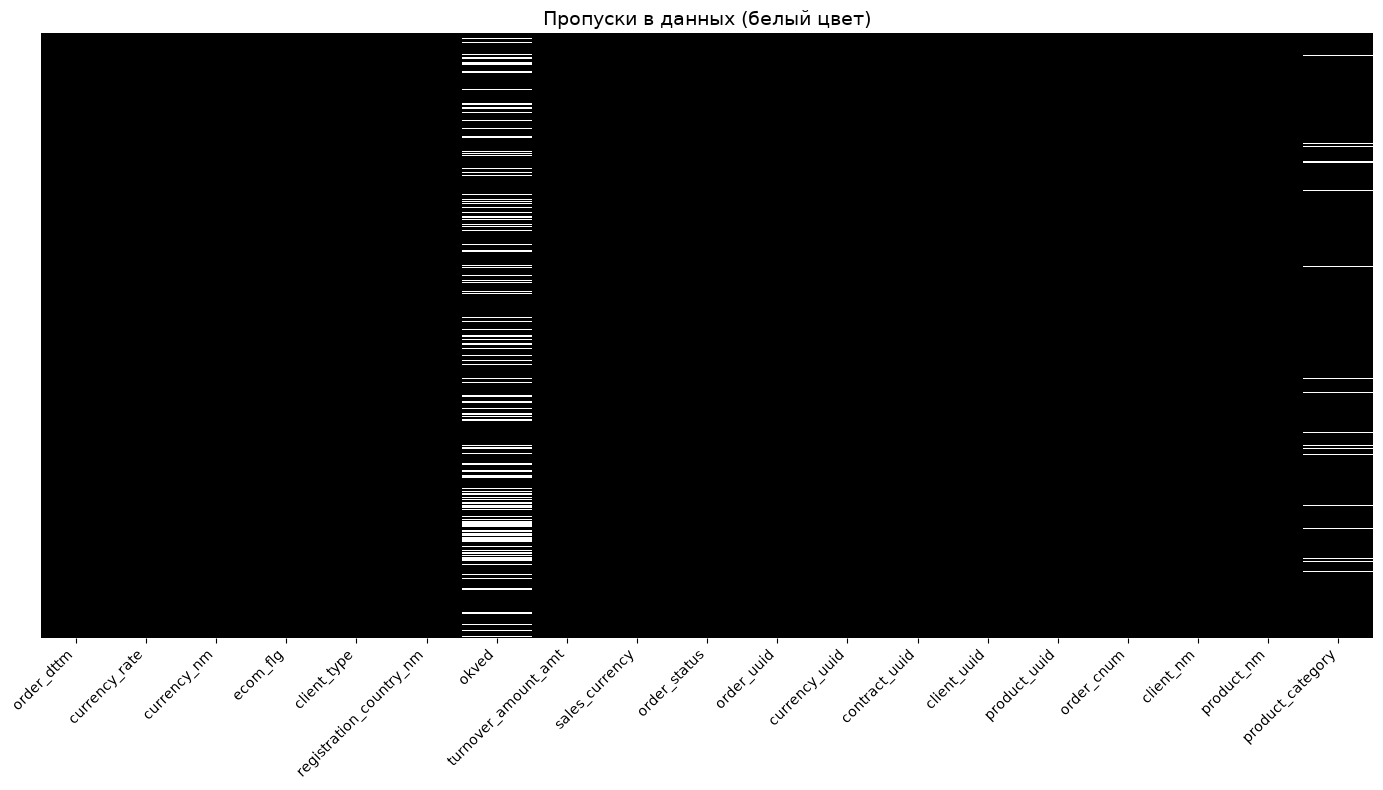


Таблица пропусков:
В датасете 19 колонок.
Есть пропуски в 6 колонках.
                         Missing Values  % of Total Values
okved                            122804               22.5
product_category                  15151                2.8
registration_country_nm              66                0.0
client_type                          54                0.0
client_nm                            54                0.0
currency_nm                           2                0.0


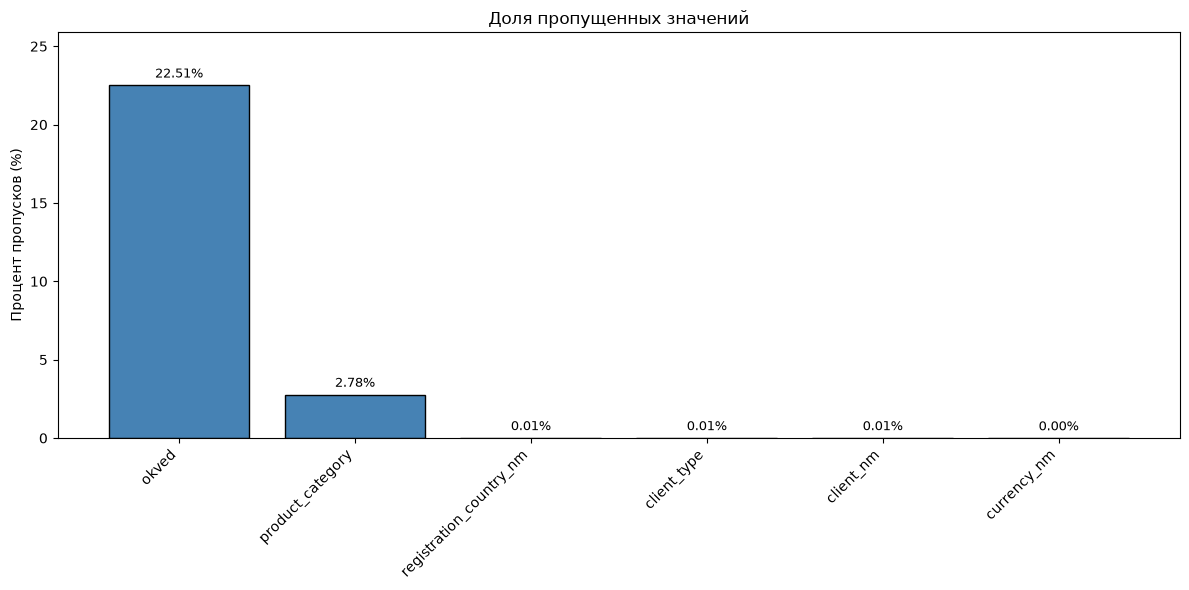

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

bf = pd.read_csv('dataset_anonymized_unprocessed.csv')
bf['order_dttm'] = pd.to_datetime(bf['order_dttm'])

# 1. Heatmap пропусков
def plot_missing(df):
    colours = ['#000000', '#ffffff']
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(df.isnull(), cmap=sns.color_palette(colours),
                cbar=False, yticklabels=False, xticklabels=True)
    ax.set_title('Пропуски в данных (белый цвет)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 2. Barplot процентов пропусков
def plot_missing_percent(df):
    missing_perc = df.isnull().mean() * 100
    missing_perc = missing_perc[missing_perc > 0].sort_values(ascending=False)
    
    if len(missing_perc) == 0:
        print("Пропусков нет")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(missing_perc.index, missing_perc.values, color='steelblue', edgecolor='black')
    ax.set_ylabel('Процент пропусков (%)')
    ax.set_title('Доля пропущенных значений')
    plt.xticks(rotation=45, ha='right')
    
    for bar, perc in zip(bars, missing_perc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f'{perc:.2f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylim(0, max(missing_perc.values) * 1.15)  # место для подписей
    plt.tight_layout()
    plt.show()

# 3. Таблица пропусков
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print(f"В датасете {df.shape[1]} колонок.\n"
          f"Есть пропуски в {mis_val_table_ren_columns.shape[0]} колонках.")
    return mis_val_table_ren_columns

plot_missing(bf)
print("\nТаблица пропусков:")
missing_table = missing_values_table(bf)
print(missing_table)
plot_missing_percent(bf)

In [5]:
# Показывать все столбцы
print(df.head(5).to_string())

                order_dttm  currency_rate currency_nm  ecom_flg client_type registration_country_nm                                                                                      okved  turnover_amount_amt sales_currency    order_status                            order_uuid                         currency_uuid                         contract_uuid                           client_uuid                          product_uuid   order_cnum           client_nm                                    product_nm        product_category
0  2025-09-24 11:37:01.000            1.0        руб.     False    Юр. лицо                  РОССИЯ                                                                Ремонт машин и оборудования                43.50            USD  implementation  b7fc3318-2d5e-31a4-f3ae-9198255d1d18  baafd897-8857-2fc9-b1bb-4bc9b37c3653  0debb53f-c7f2-973b-daf5-aab71cba0d9c  26e1c1e3-7628-d433-7168-554426f7e904  8c52f6ce-68ca-7002-8d96-3fd04fc4ee41  НГЦБ-147540     ТОО "ПромТехно

#### Обработка пропусков и типов данных в категориальных признаках 

In [6]:
# Удалить записи без названия клиента
df = df.dropna(subset=['client_nm'])

# Дата к datetime
df['order_dttm'] = pd.to_datetime(df['order_dttm'])

# Результат
print(f"Осталось строк: {len(df)}")
print(f"Диапазон дат: {df['order_dttm'].min()} – {df['order_dttm'].max()}")
print("\nТипы данных:\n" + df.dtypes.to_string())

Осталось строк: 545452
Диапазон дат: 2024-01-03 11:23:40 – 2026-06-11 19:44:46

Типы данных:
order_dttm                 datetime64[us]
currency_rate                     float64
currency_nm                           str
ecom_flg                             bool
client_type                           str
registration_country_nm               str
okved                                 str
turnover_amount_amt               float64
sales_currency                        str
order_status                          str
order_uuid                            str
currency_uuid                         str
contract_uuid                         str
client_uuid                           str
product_uuid                          str
order_cnum                            str
client_nm                             str
product_nm                            str
product_category                      str


In [7]:
# Заполнить пропуски client_type
df['client_type'] = df['client_type'].fillna(
    df['okved'].notna().map({True: 'Юр. лицо', False: 'Физ. лицо'})
)

# Проверить, что пропусков не осталось
print("Пропуски client_type после заполнения:", df['client_type'].isnull().sum())
print("\nРаспределение client_type:")
print(df['client_type'].value_counts())

Пропуски client_type после заполнения: 0

Распределение client_type:
client_type
Юр. лицо                          468805
Индивидуальный предприниматель     36544
Физ. лицо                          31597
Юр. лицо, за пределами РФ           8506
Name: count, dtype: int64


In [8]:
# Вычислить моду (самое частое значение) для столбца registration_country_nm
most_frequent_country = df['registration_country_nm'].mode()[0]

# Заполнить пропуски модой
df['registration_country_nm'] = df['registration_country_nm'].fillna(most_frequent_country)

# Проверить результат
print("Осталось пропусков registration_country_nm:", df['registration_country_nm'].isnull().sum())

Осталось пропусков registration_country_nm: 0


In [9]:
# Создать словарь product_nm -> product_category (только непустые категории)
known_categories = df[df['product_category'].notna()].drop_duplicates('product_nm').set_index('product_nm')['product_category'].to_dict()

# Заполнить пропуски, где название товара есть в словаре
df['product_category'] = df['product_category'].fillna(df['product_nm'].map(known_categories))

# Определить маску для оставшихся пропусков
remaining_missing = df['product_category'].isna()

# Сколько осталось пропусков и по каким названиям
print("Осталось пропусков после заполнения product_category:", remaining_missing.sum())
missing_product_names = df.loc[remaining_missing, 'product_nm'].unique()
print(f"\nУникальных названий без категории: {len(missing_product_names)}")

Осталось пропусков после заполнения product_category: 42

Уникальных названий без категории: 3


In [10]:
# Заполнить оставшиеся пропуски значением 'Другое'
df['product_category'] = df['product_category'].fillna('Другое')

# Проверить, что пропусков больше нет
print("Пропусков product_category после заполнения:", df['product_category'].isnull().sum())

Пропусков product_category после заполнения: 0


In [11]:
print("\nПропуски:")
print(df.isnull().sum())


Пропуски:
order_dttm                      0
currency_rate                   0
currency_nm                     2
ecom_flg                        0
client_type                     0
registration_country_nm         0
okved                      122750
turnover_amount_amt             0
sales_currency                  0
order_status                    0
order_uuid                      0
currency_uuid                   0
contract_uuid                   0
client_uuid                     0
product_uuid                    0
order_cnum                      0
client_nm                       0
product_nm                      0
product_category                0
dtype: int64


In [12]:
# Заполнить currency_nm модой
df['currency_nm'] = df['currency_nm'].fillna(df['currency_nm'].mode()[0])
df['registration_country_nm'] = df['registration_country_nm'].fillna(df['registration_country_nm'].mode()[0])

# Проверка
print("Пропусков currency_nm:", df['currency_nm'].isnull().sum())
print("Пропусков registration_country_nm:", df['registration_country_nm'].isnull().sum())

Пропусков currency_nm: 0
Пропусков registration_country_nm: 0


#### Обработка ОКВЭД

In [13]:
# 1. Для физ. лиц и ИП признак "Нет ОКВЭД" (осмысленное отсутствие)
mask_no_okved = df['client_type'].isin(['Физ. лицо', 'Индивидуальный предприниматель'])
df.loc[mask_no_okved & df['okved'].isnull(), 'okved'] = 'Нет ОКВЭД'

# Проверка
print("Осталось пропусков okved:", df['okved'].isnull().sum())

Осталось пропусков okved: 67034


In [14]:
# Подготовка данных для модели OKVED (только юр. лица)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

# Берём только юр. лиц (у них могут быть пропуски OKVED)
legal_df = df[df['client_type'] == 'Юр. лицо'].copy()

# Агрегируем последовательности товаров по заказам
order_products = legal_df.groupby('order_uuid')['product_uuid'].apply(
    lambda x: ' '.join(x.astype(str))
).reset_index()
order_products.columns = ['order_uuid', 'product_sequence']

# Добавляем OKVED и client_uuid
order_info = legal_df[['order_uuid', 'okved', 'client_uuid']].drop_duplicates('order_uuid')
order_products = order_products.merge(order_info, on='order_uuid', how='left')

# Разделяем на известные и неизвестные OKVED
known = order_products[order_products['okved'].notna() & (order_products['okved'] != '')].copy()
unknown = order_products[order_products['okved'].isnull() | (order_products['okved'] == '')].copy()

print(f"Заказов с известным OKVED: {len(known)}")
print(f"Заказов с неизвестным OKVED: {len(unknown)}")

Заказов с известным OKVED: 138435
Заказов с неизвестным OKVED: 21619


In [15]:
# Для каждого клиента-юридического лица вычислить его самый частый OKVED
#    (только по тем заказам, где OKVED заполнен)
client_okved_mode = (
    df[df['client_type'] == 'Юр. лицо']
    .groupby('client_uuid')['okved']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
)

# 2. Заполнить пропуски у тех клиентов, у которых есть мода
mask = (df['client_type'] == 'Юр. лицо') & (df['okved'].isnull())
df.loc[mask, 'okved'] = df.loc[mask, 'client_uuid'].map(client_okved_mode)

# 3. Все оставшиеся пропуски – "Не указан"
df['okved'] = df['okved'].fillna('Не указан')

# 4. Проверка
print("Пропусков OKVED после заполнения:", df['okved'].isnull().sum())
print("\nРаспределение OKVED (топ-10):")
print(df['okved'].value_counts().head(10))

Пропусков OKVED после заполнения: 0

Распределение OKVED (топ-10):
okved
Не указан                                                                                             67034
Нет ОКВЭД                                                                                             55716
Производство электромонтажных работ                                                                   26214
Строительство жилых и нежилых зданий                                                                  25538
Производство компьютеров и периферийного оборудования                                                 24291
Ремонт машин и оборудования                                                                           18891
Ремонт электрического оборудования                                                                    13713
Строительство инженерных коммуникаций для водоснабжения и водоотведения, газоснабжения                11476
Торговля оптовая компьютерами, периферийными устройствами к ком

In [16]:
print("\nПропуски:")
print(df.isnull().sum())


Пропуски:
order_dttm                 0
currency_rate              0
currency_nm                0
ecom_flg                   0
client_type                0
registration_country_nm    0
okved                      0
turnover_amount_amt        0
sales_currency             0
order_status               0
order_uuid                 0
currency_uuid              0
contract_uuid              0
client_uuid                0
product_uuid               0
order_cnum                 0
client_nm                  0
product_nm                 0
product_category           0
dtype: int64


In [17]:
# Валюта продажи товаров - частота
print("Распределение sales_currency:")
currency_counts = df['sales_currency'].value_counts()
print(currency_counts)


Распределение sales_currency:
sales_currency
USD    410335
RUB    135117
Name: count, dtype: int64


#### Числовые признаки

Уникальные значения currency_nm:
currency_nm
руб.        460390
USD          80723
KZT           2606
CNY           1712
CNY (ЦБ)        14
USD (ЦБ)         4
EUR              3
Name: count, dtype: int64


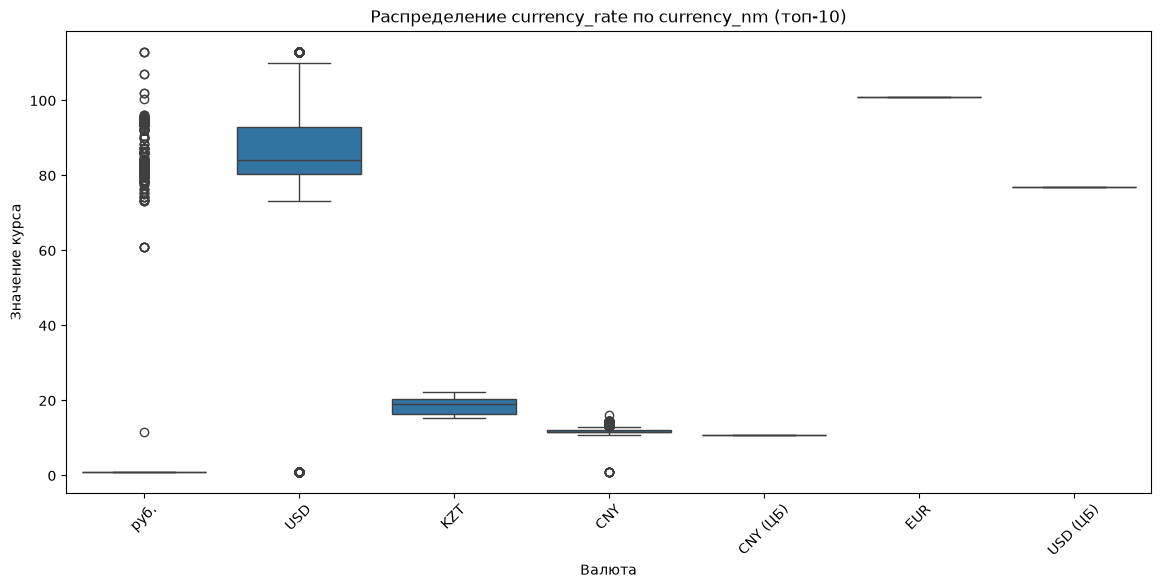

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Какие валюты вообще есть в currency_nm?
print("Уникальные значения currency_nm:")
print(df['currency_nm'].value_counts().head(20))

# 2. Распределение currency_rate по currency_nm (топ-10)
top_currencies = df['currency_nm'].value_counts().head(10).index
plt.figure(figsize=(14, 6))
sns.boxplot(x='currency_nm', y='currency_rate', data=df[df['currency_nm'].isin(top_currencies)])
plt.xticks(rotation=45)
plt.title('Распределение currency_rate по currency_nm (топ-10)')
plt.xlabel('Валюта')
plt.ylabel('Значение курса')
plt.show()


Средний курс и количество записей по currency_nm:


,mean_rate,std_rate,count
currency_nm,,,
руб.,1.167883,3.741125,460390
USD,84.938920,14.954835,80723
KZT,18.694928,2.033902,2606
CNY,11.846605,1.098974,1712
CNY (ЦБ),10.897900,0.000000,14
USD (ЦБ),76.900000,0.000000,4
EUR,101.000000,0.000000,3


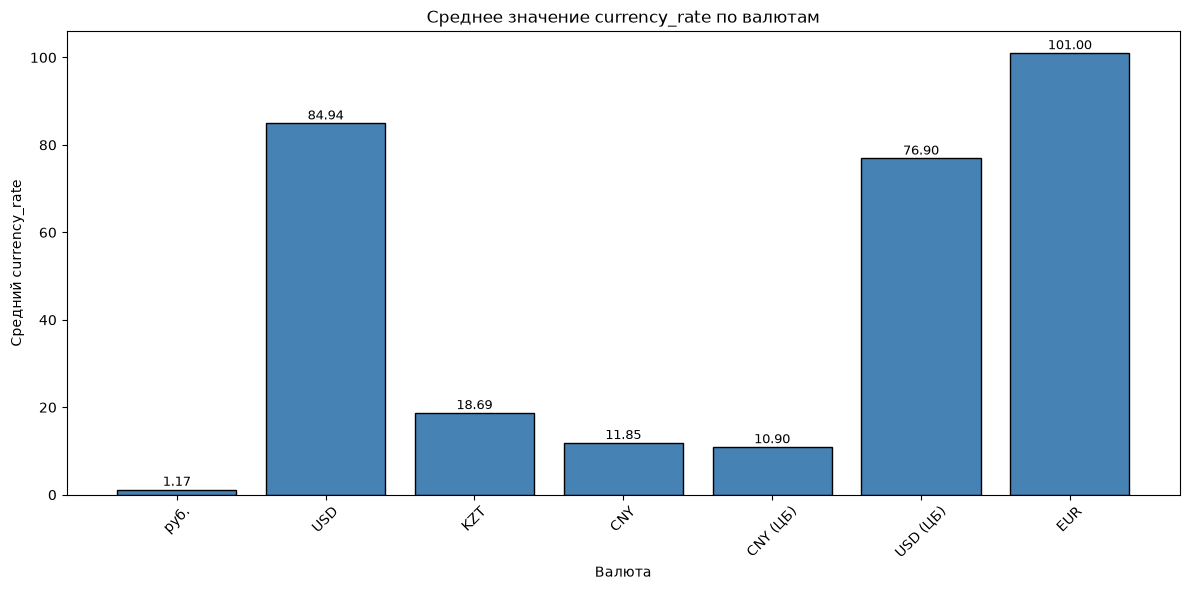

In [19]:
# Средний курс и количество записей для каждой валюты
rate_summary = df.groupby('currency_nm').agg(
    mean_rate=('currency_rate', 'mean'),
    std_rate=('currency_rate', 'std'),
    count=('currency_rate', 'count')
).sort_values('count', ascending=False)

print("Средний курс и количество записей по currency_nm:")
display(rate_summary)

# Визуализация: barplot среднего курса
plt.figure(figsize=(12, 6))
bars = plt.bar(rate_summary.index, rate_summary['mean_rate'], color='steelblue', edgecolor='black')
plt.xlabel('Валюта')
plt.ylabel('Средний currency_rate')
plt.title('Среднее значение currency_rate по валютам')
plt.xticks(rotation=45)
# Добавим подписи значений над столбцами
for bar, val in zip(bars, rate_summary['mean_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

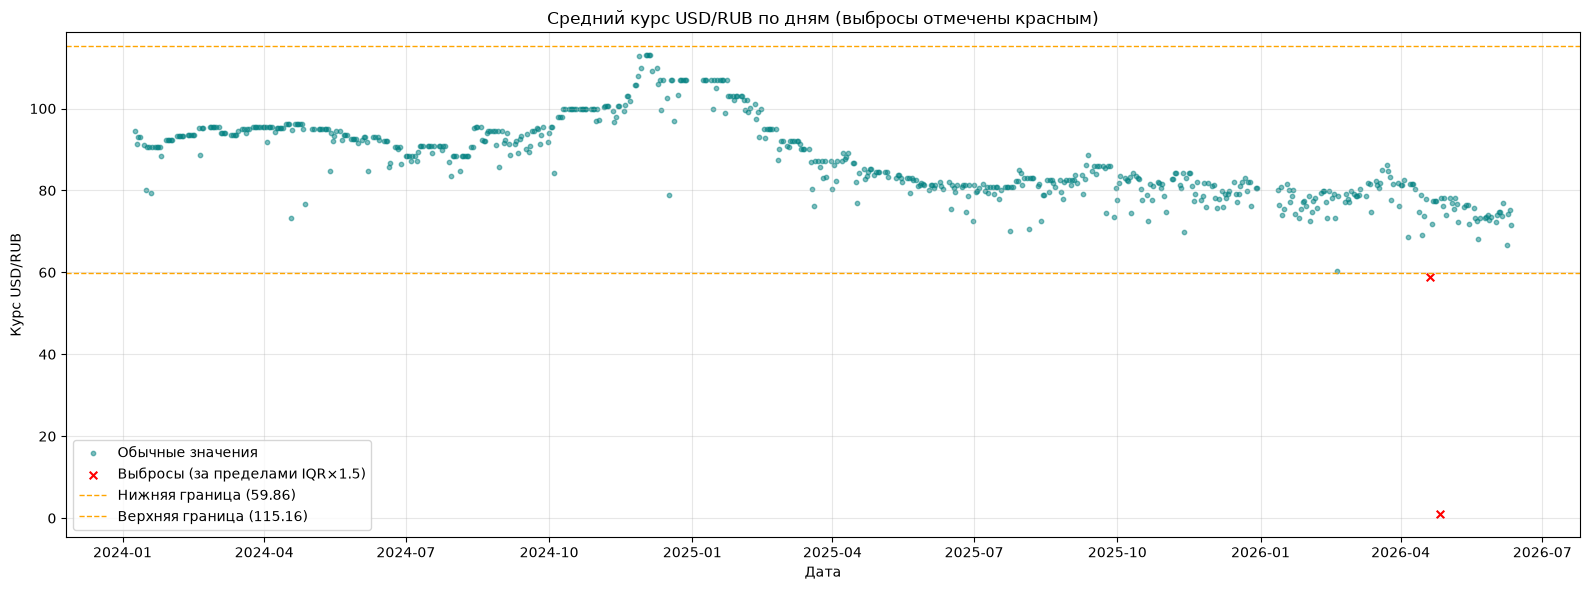

Даты с аномальным курсом USD/RUB:
order_date
2026-04-20    58.792781
2026-04-26     1.000000
Name: currency_rate, dtype: float64


In [20]:
# Проверка курса только по USD на "нормальность"
usd_rates = df[df['currency_nm'] == 'USD'].copy()
usd_rates['order_date'] = usd_rates['order_dttm'].dt.date
daily_usd = usd_rates.groupby('order_date')['currency_rate'].mean().sort_index()

# Подготовка данных
usd_rates = df[df['currency_nm'] == 'USD'].copy()
usd_rates['order_date'] = usd_rates['order_dttm'].dt.date
daily_usd = usd_rates.groupby('order_date')['currency_rate'].mean().sort_index()

# Определить порог для выбросов через IQR
Q1 = daily_usd.quantile(0.25)
Q3 = daily_usd.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Маска выбросов
outliers = (daily_usd < lower_bound) | (daily_usd > upper_bound)

plt.figure(figsize=(16, 6))

# Обычные точки
plt.scatter(daily_usd.index[~outliers], daily_usd[~outliers], 
            color='teal', alpha=0.5, s=10, label='Обычные значения')

# Выбросы – красным и крупнее
plt.scatter(daily_usd.index[outliers], daily_usd[outliers], 
            color='red', s=30, marker='x', label=f'Выбросы (за пределами IQR×1.5)')

# Добавим границы IQR
plt.axhline(y=lower_bound, color='orange', linestyle='--', linewidth=1, label=f'Нижняя граница ({lower_bound:.2f})')
plt.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=1, label=f'Верхняя граница ({upper_bound:.2f})')

plt.title('Средний курс USD/RUB по дням (выбросы отмечены красным)')
plt.xlabel('Дата')
plt.ylabel('Курс USD/RUB')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Выведем даты и значения выбросов
print("Даты с аномальным курсом USD/RUB:")
print(daily_usd[outliers])

In [21]:
def replace_outliers_with_local_median(series, iqr_multiplier=1.5, window=5):
    # 1. Обнаружение выбросов через глобальный IQR
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    
    # 2. Замена выбросов на локальную медиану
    series_clean = series.copy()
    replacements = []
    for date, value in series[outliers].items():
        # Определяет индексы окна
        idx = series.index
        pos = idx.get_loc(date)
        start = max(0, pos - window)
        end = min(len(idx), pos + window + 1)
        window_indices = idx[start:end]
        # Убирает саму дату
        window_indices = window_indices.drop(date, errors='ignore')
        if len(window_indices) == 0:
            # Если нет соседей, использует глобальную медиану
            new_val = series.median()
        else:
            new_val = series.loc[window_indices].median()
        series_clean.loc[date] = new_val
        replacements.append((date, value, new_val))
    
    # Проверка
    print(f"Всего заменено: {len(replacements)}")
    for date, old, new in replacements:
        print(f"{date}: было {old:.2f}, стало {new:.2f}")
    
    return series_clean, replacements

In [22]:
daily_usd_clean, replaced = replace_outliers_with_local_median(
    daily_usd,
    iqr_multiplier=1.5,  # стандартный IQR
    window=5             # ±5 дней
)

Всего заменено: 2
2026-04-20: было 58.79, стало 76.02
2026-04-26: было 1.00, стало 77.35


2026-04-20: 58.79 -> 76.02
2026-04-26: 1.00 -> 77.35


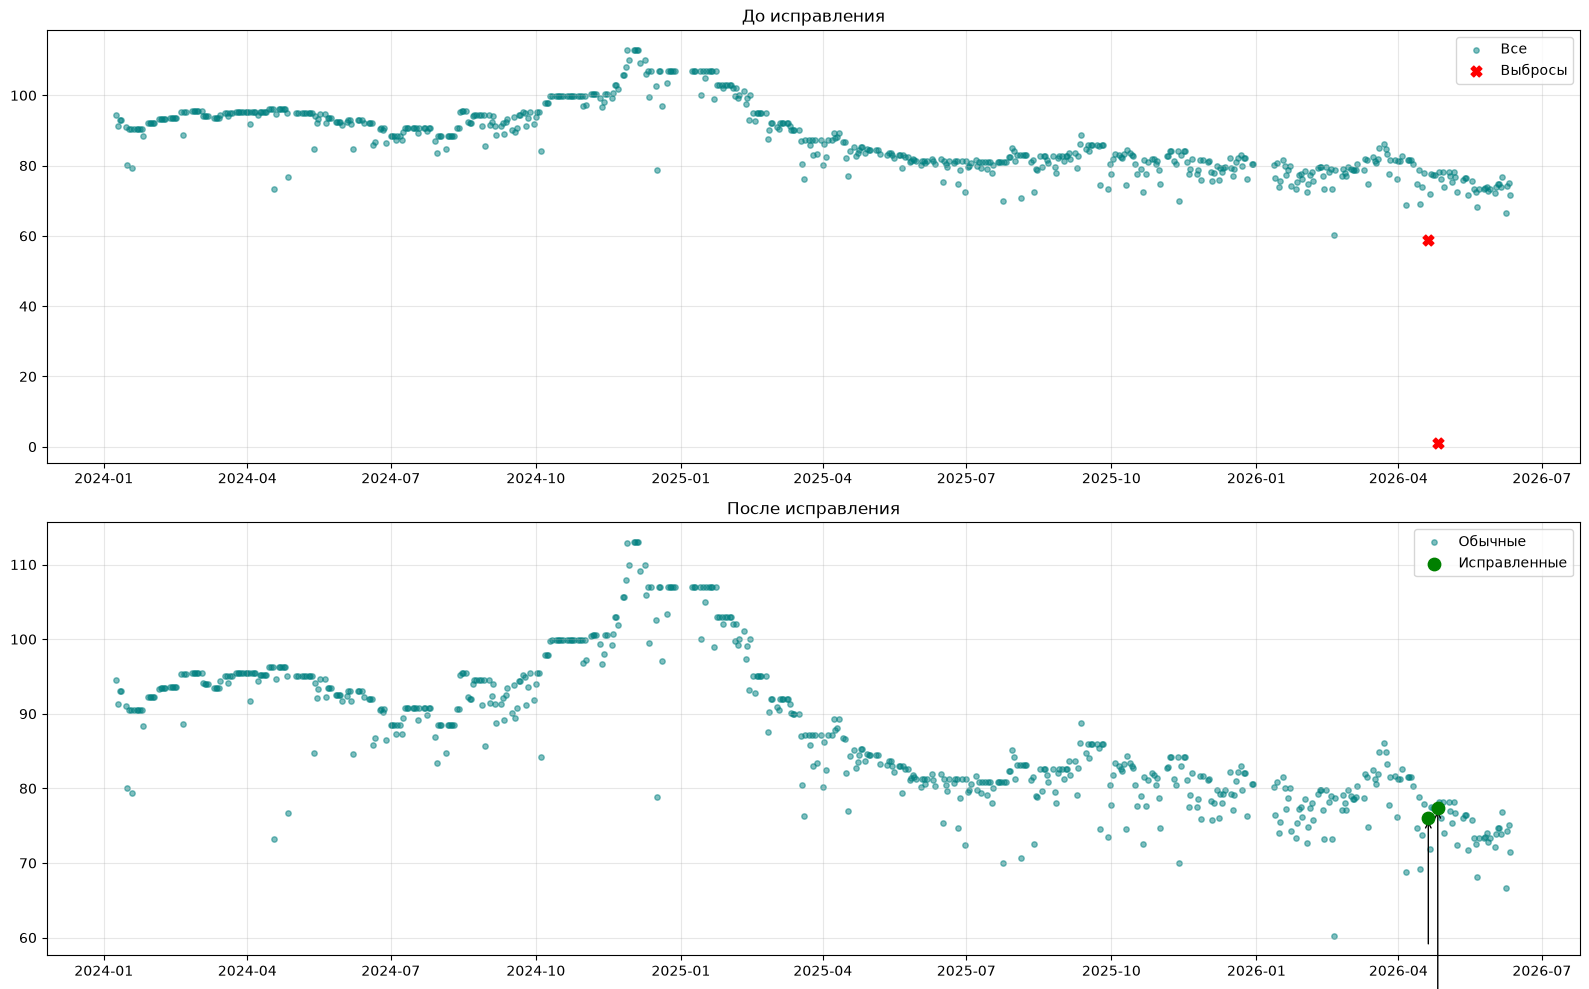

Справочник готов. Пример: 2024-01-09    94.500000
2024-01-10    91.278302
2024-01-11    93.000000
2024-01-12    93.000000
2024-01-13    93.000000
Freq: D, Name: currency_rate, dtype: float64


In [23]:
# Преобразуем индекс daily_usd в DatetimeIndex
daily_usd.index = pd.to_datetime(daily_usd.index)

# Копии
daily_usd_raw = daily_usd.copy()
daily_usd_clean = daily_usd.copy()

# Функция замены на медиану соседей
def get_neighbors_median(series, target_date, window=5):
    date_idx = series.index.get_loc(target_date)
    start = max(0, date_idx - window)
    end = min(len(series), date_idx + window + 1)
    neighbors = series.iloc[start:end].drop(target_date, errors='ignore')
    return neighbors.median() if len(neighbors) > 0 else series.median()

# Исправляем выбросы
outlier_dates = [pd.Timestamp('2026-04-20'), pd.Timestamp('2026-04-26')]
for dt in outlier_dates:
    old_val = daily_usd_clean.loc[dt]
    new_val = get_neighbors_median(daily_usd_clean, dt, window=5)
    daily_usd_clean.loc[dt] = new_val
    print(f"{dt.date()}: {old_val:.2f} -> {new_val:.2f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
ax1.scatter(daily_usd_raw.index, daily_usd_raw.values, color='teal', alpha=0.5, s=15, label='Все')
ax1.scatter(outlier_dates, daily_usd_raw[outlier_dates], color='red', s=60, marker='X', zorder=5, label='Выбросы')
ax1.set_title('До исправления')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.scatter(daily_usd_clean.index, daily_usd_clean.values, color='teal', alpha=0.5, s=15, label='Обычные')
ax2.scatter(outlier_dates, daily_usd_clean[outlier_dates], color='green', s=80, marker='o', zorder=5, label='Исправленные')
for dt in outlier_dates:
    ax2.annotate('', xy=(dt, daily_usd_clean.loc[dt]), xytext=(dt, daily_usd_raw.loc[dt]),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2.set_title('После исправления')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Справочник
full_dates = pd.date_range(start=daily_usd_clean.index.min(), end=daily_usd_clean.index.max(), freq='D')
usd_rate_series = daily_usd_clean.reindex(full_dates, method='ffill')
if usd_rate_series.isnull().any():
    usd_rate_series = usd_rate_series.fillna(method='bfill')
print("Справочник готов. Пример:", usd_rate_series.head())

In [24]:
import pickle
with open('usd_rate_series.pkl', 'wb') as f:
    pickle.dump(usd_rate_series, f)

In [25]:
zero_orders = df[df['turnover_amount_amt'] == 0]
print(f"Нулевых заказов: {len(zero_orders)}")
print("Статусы нулевых заказов:")
for status, cnt in zero_orders['order_status'].value_counts().items():
    print(f"  {status}: {cnt}")
zero_orders = df[df['turnover_amount_amt'] == 0]
# Проверка наличия заказов без товаров = 0
items_per_order = zero_orders.groupby('order_uuid')['product_uuid'].nunique()
min_items = items_per_order.min()
print(f"Минимальное количество товаров в заказе: {min_items}")


Нулевых заказов: 2994
Статусы нулевых заказов:
  in processing: 2990
  implementation: 4
Минимальное количество товаров в заказе: 1


In [26]:
# 1. Приведение даты заказа к формату datetime (без времени)
df['order_date'] = df['order_dttm'].dt.date
df['order_date_dt'] = pd.to_datetime(df['order_date'])

# 2. Сопоставление курса USD/RUB на дату заказа
df['usd_rate'] = df['order_date_dt'].map(usd_rate_series)

# 3. Если дата отсутствует в справочнике, заполняем предыдущим известным курсом
df['usd_rate'] = df['usd_rate'].ffill()

# 4. Конвертация оборотов: RUB → USD делением на курс, USD остаётся без изменений
df['amount_usd'] = df['turnover_amount_amt']
mask_rub = df['sales_currency'] == 'RUB'
df.loc[mask_rub, 'amount_usd'] = df.loc[mask_rub, 'turnover_amount_amt'] / df.loc[mask_rub, 'usd_rate']

# 5. Проверка результата
print("Пример RUB-заказов после конвертации:")
display(df[mask_rub][['order_date', 'sales_currency', 'turnover_amount_amt', 'usd_rate', 'amount_usd']].head())

print("\nПример USD-заказов (сумма не менялась):")
display(df[~mask_rub][['order_date', 'sales_currency', 'turnover_amount_amt', 'amount_usd']].head())

print("\nМинимальная/максимальная сумма в USD:", df['amount_usd'].min(), df['amount_usd'].max())
print("Количество нулевых сумм:", (df['amount_usd'] == 0).sum())

Пример RUB-заказов после конвертации:


,order_date,sales_currency,turnover_amount_amt,usd_rate,amount_usd
410335,2026-05-05,RUB,0.0,75.37561,0.0
410336,2026-05-05,RUB,0.0,75.37561,0.0
410337,2026-05-05,RUB,0.0,75.37561,0.0
410338,2026-05-05,RUB,0.0,75.37561,0.0
410339,2026-05-05,RUB,0.0,75.37561,0.0



Пример USD-заказов (сумма не менялась):


,order_date,sales_currency,turnover_amount_amt,amount_usd
0,2025-09-24,USD,43.50,43.50
1,2025-09-01,USD,261.52,261.52
2,2025-08-27,USD,38.81,38.81
3,2025-07-22,USD,900.67,900.67
4,2025-09-16,USD,7.75,7.75



Минимальная/максимальная сумма в USD: 0.0 26598513.992778234
Количество нулевых сумм: 2994


In [27]:
# Сначала агрегируем заказы, чтобы выполнить анализ заказа
orders = df.groupby('order_uuid').agg(
    client_uuid=('client_uuid', 'first'),
    order_date=('order_dttm', 'first'),               # дата заказа
    total_amount=('amount_usd', 'sum'),               # сумма заказа (всех позиций)
    ecom_flg=('ecom_flg', 'first'),
    client_type=('client_type', 'first'),
    country=('registration_country_nm', 'first'),
    okved=('okved', 'first'),
    sales_currency=('sales_currency', 'first')
).reset_index()

Среднее (mean): 3,449.76 USD
Стандартное отклонение (std): 70,603.41 USD
Медиана (50%): 443.26 USD
Интерквартильный размах (IQR): 1,394.17 USD


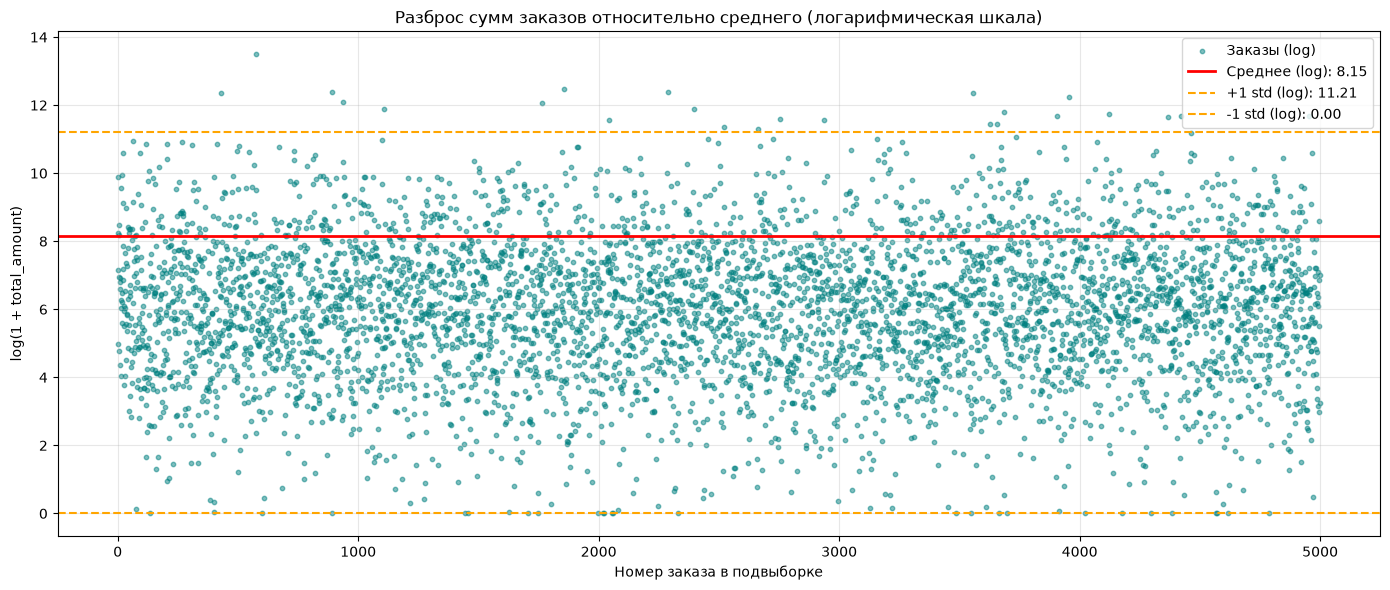

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Статистики по сумме заказа (total_amount)
# =====================================================
mean_val = orders['total_amount'].mean()
std_val = orders['total_amount'].std()
median_val = orders['total_amount'].median()
q1_val = orders['total_amount'].quantile(0.25)
q3_val = orders['total_amount'].quantile(0.75)

print(f"Среднее (mean): {mean_val:,.2f} USD")
print(f"Стандартное отклонение (std): {std_val:,.2f} USD")
print(f"Медиана (50%): {median_val:,.2f} USD")
print(f"Интерквартильный размах (IQR): {q3_val - q1_val:,.2f} USD")

# =====================================================
# Визуализация разброса сумм заказов (логарифмическая шкала)
# =====================================================
np.random.seed(42)
sample = orders['total_amount'].sample(min(5000, len(orders)), random_state=42)

log_sample = np.log1p(sample)
log_mean = np.log1p(mean_val)
log_std_plus = np.log1p(mean_val + std_val) - log_mean
log_std_minus = log_mean - np.log1p(max(0, mean_val - std_val))

plt.figure(figsize=(14,6))
plt.scatter(range(len(log_sample)), log_sample, alpha=0.5, s=10, color='teal', label='Заказы (log)')
plt.axhline(log_mean, color='red', linestyle='-', linewidth=2, label=f'Среднее (log): {log_mean:.2f}')
plt.axhline(log_mean + log_std_plus, color='orange', linestyle='--', label=f'+1 std (log): {log_mean+log_std_plus:.2f}')
plt.axhline(log_mean - log_std_minus, color='orange', linestyle='--', label=f'-1 std (log): {log_mean-log_std_minus:.2f}')

plt.xlabel('Номер заказа в подвыборке')
plt.ylabel('log(1 + total_amount)')
plt.title('Разброс сумм заказов относительно среднего (логарифмическая шкала)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

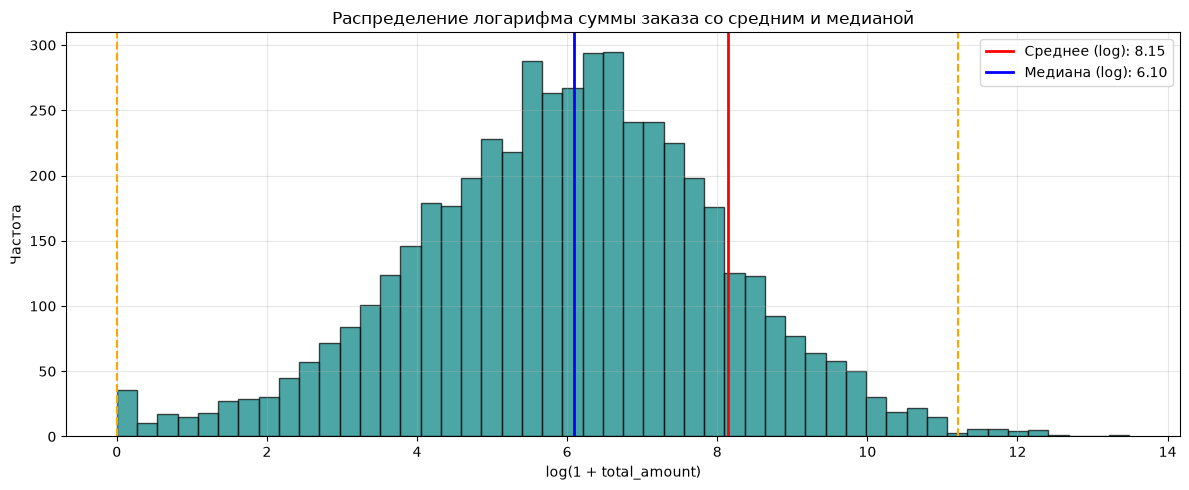

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Статистики по сумме заказа (total_amount)
# =====================================================
mean_val = orders['total_amount'].mean()
std_val = orders['total_amount'].std()
median_val = orders['total_amount'].median()

# Логарифмические статистики
log_mean = np.log1p(mean_val)
log_std_plus = np.log1p(mean_val + std_val) - log_mean
log_std_minus = log_mean - np.log1p(max(0, mean_val - std_val))

# =====================================================
# Гистограмма логарифма суммы заказа
# =====================================================
np.random.seed(42)
sample = orders['total_amount'].sample(min(5000, len(orders)), random_state=42)
log_sample = np.log1p(sample)

plt.figure(figsize=(12,5))
plt.hist(log_sample, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(log_mean, color='red', linewidth=2, label=f'Среднее (log): {log_mean:.2f}')
plt.axvline(np.log1p(median_val), color='blue', linewidth=2, label=f'Медиана (log): {np.log1p(median_val):.2f}')
plt.axvline(log_mean + log_std_plus, color='orange', linestyle='--')
plt.axvline(log_mean - log_std_minus, color='orange', linestyle='--')
plt.xlabel('log(1 + total_amount)')
plt.ylabel('Частота')
plt.title('Распределение логарифма суммы заказа со средним и медианой')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
zero_orders_mask = orders['total_amount'] == 0
zero_orders_count = zero_orders_mask.sum()
total_orders = len(orders)

print(f"Нулевых заказов: {zero_orders_count} из {total_orders} ({zero_orders_count/total_orders*100:.2f}%)")

Нулевых заказов: 828 из 182368 (0.45%)


In [31]:
Q1_ord = orders['total_amount'].quantile(0.25)
Q3_ord = orders['total_amount'].quantile(0.75)
IQR_ord = Q3_ord - Q1_ord
upper_bound_ord = Q3_ord + 1.5 * IQR_ord

outliers_iqr_ord = orders['total_amount'] > upper_bound_ord
outliers_iqr_ord_count = outliers_iqr_ord.sum()
print(f"Верхняя граница (Q3 + 1.5*IQR): {upper_bound_ord:,.2f} USD")
print(f"Заказов выше этой границы: {outliers_iqr_ord_count} ({outliers_iqr_ord_count/total_orders*100:.2f}%)")

Верхняя граница (Q3 + 1.5*IQR): 3,599.44 USD
Заказов выше этой границы: 23082 (12.66%)


In [32]:
p99_ord = orders['total_amount'].quantile(0.99)
outliers_p99_ord = orders['total_amount'] > p99_ord
outliers_p99_ord_count = outliers_p99_ord.sum()
print(f"99-й процентиль: {p99_ord:,.2f} USD")
print(f"Заказов выше 99-го процентиля: {outliers_p99_ord_count} ({outliers_p99_ord_count/total_orders*100:.2f}%)")

99-й процентиль: 42,568.20 USD
Заказов выше 99-го процентиля: 1824 (1.00%)


In [33]:
# Проверка полных дубликатов
n_duplicates_full = df.duplicated().sum()
print(f"Полных дубликатов строк: {n_duplicates_full}")

Полных дубликатов строк: 5265


In [34]:
# 1. Удаляем полные дубликаты
df = df.drop_duplicates()
print(f"Размер после удаления дубликатов: {df.shape}")

Размер после удаления дубликатов: (540187, 23)


In [35]:
# Сохранить
df.to_parquet('cleaned_data.parquet', index=False)
orders.to_parquet('orders.parquet', index=False)